In [1]:
import os, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

sys.path.insert(0, '/root/work/Papers')
import paper_style as ps; ps.set_style(); ps.compact_12()

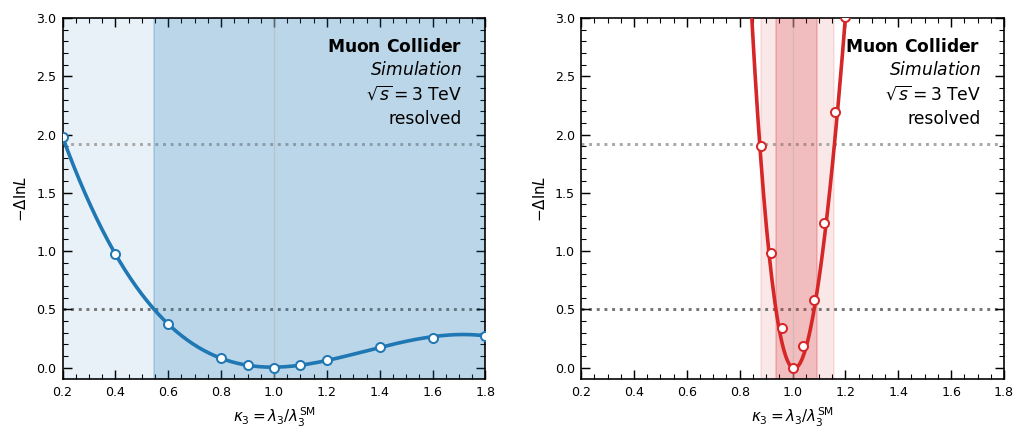

In [2]:

# ==========================================
# 1. 在這裡替換成你自己的數據 (YOUR DATA HERE)
# ==========================================

# --- 左圖數據 (3 TeV) ---
x_data_left = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
y_data_left = np.array([1.979128700237756, 0.9747422305260196, 0.37481869568439574, 0.07950971455863609, 0.018069958961136834, 0.0, 0.020455775416379218, 0.06351911551906042, 0.18081546873601617, 0.2563482550651468, 0.2751343986907955])
# y=0.5 對應的 x 範圍 (較深色陰影)
range_05_left = [0.546, 3]
# y=1.96 對應的 x 範圍 (較淺色陰影)
range_196_left = [0, 1.8] # 這裡設定到 1.8 是因為曲線右邊沒有再超過 1.96

# --- 右圖數據 (10 TeV) ---
# x_data_right = np.array([0.2, 0.4, 0.6, 0.8, 0.84, 0.88, 0.92, 0.96, 1, 1.04, 1.08, 1.12, 1.16, 1.2, 1.4, 1.6, 1.8])
# y_data_right = np.array([120.54228778460114, 63.89926977482702, 24.777416087634457, 5.3480654507179874, 3.330502060135071, 1.8997300463962556, 0.9791748911067479, 0.3419043583875645, 0.0, 0.1875475784030307, 0.5838913955303191, 1.2408765062184166, 2.1933176605294813, 3.0086811893898284, 11.155761794152092, 17.964321313838965, 18.624092537231206])
x_data_right = np.array([0.8, 0.84, 0.88, 0.92, 0.96, 1, 1.04, 1.08, 1.12, 1.16, 1.2, 1.4])
y_data_right = np.array([5.3480654507179874, 3.330502060135071, 1.8997300463962556, 0.9791748911067479, 0.3419043583875645, 0.0, 0.1875475784030307, 0.5838913955303191, 1.2408765062184166, 2.1933176605294813, 3.0086811893898284, 11.155761794152092])
# y=0.5 對應的 x 範圍 (較深色陰影)
range_05_right = [0.936, 1.091]
# y=1.96 對應的 x 範圍 (較淺色陰影)
range_196_right = [0.882, 1.155]


# ==========================================
# 2. 繪圖與排版設定 (Plotting Layout)
# ==========================================

# 建立畫布與子圖 (1x2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.0, 3.5))

def setup_axes(ax, x_data, y_data, range_05, range_196, color, energy_label, x_limits, y_limits):
    """輔助函式：統一設定子圖樣式"""

    # 1. 繪製平滑曲線 (使用 numpy 的 4 次多項式擬合)
    coeffs = np.polyfit(x_data, y_data, 4)
    
    if ax == ax2:
        coeffs[-1] -= 0.11
    poly_func = np.poly1d(coeffs)

    # 在可視範圍內產生平滑曲線的點
    x_smooth = np.linspace(x_limits[0], x_limits[1], 300)
    y_smooth = poly_func(x_smooth)

    # 2. 繪製背景輔助線與兩種陰影區域
    # 水平虛線 y=0.5 與 y=1.92
    ax.axhline(0.5, color='0.45', linestyle=':', zorder=1)
    ax.axhline(1.92, color='0.65', linestyle=':', zorder=1)

    # 垂直實線 x=1.0 (保留原本中間的基準線)
    ax.axvline(1.0,  color='0.7',  lw=0.7, alpha=0.5)

    # 繪製兩種陰影 (淺色對應 1.96，深色對應 0.5)
    # 淺色陰影 (alpha 較小)
    ax.axvspan(range_196[0], range_196[1], color=color, alpha=0.1, zorder=1)
    # 深色陰影 (alpha 較大)，會疊加在淺色上面形成圖片中的視覺效果
    ax.axvspan(range_05[0], range_05[1], color=color, alpha=0.22, zorder=2)

    # 3. 繪製曲線與數據點 (白底空心圓)
    ax.plot(x_smooth, y_smooth, color=color, linewidth=2, zorder=4)
    ax.plot(x_data, y_data, marker='o', ls='none', mfc='white', mec=color, mew=1.1, ms=5.0, zorder=5)

    # 4. 設定軸標籤與範圍
    ax.set_xlabel(r'$\kappa_3 = \lambda_3/\lambda_3^{\rm{SM}}$')
    ax.set_ylabel(r'$-\Delta\ln L$')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)

    # 5. 設定刻度樣式 (向內、顯示副刻度、四周都有刻度)
#     ax.minorticks_on()
#     ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=14)
#     ax.tick_params(which='major', length=6, width=1.2)
#     ax.tick_params(which='minor', length=3, width=1)
    ax.set_xticks(np.arange(0.2, 1.81, 0.2))
    ps.hep_tag(ax, [rf'$\sqrt{{s}}=3$ TeV', 'resolved'], loc='upper right', simulation=True)

# 統一 X, Y 軸極限值 (根據新圖)
shared_x_limits = (0.2, 1.8)
shared_y_limits = (-0.1, 3.0)

# 套用設定到左圖 (藍色)
setup_axes(ax1, x_data_left, y_data_left, range_05_left, range_196_left,
           color=ps.C_3TEV, energy_label=r"$\sqrt{s} = 3$ TeV",
           x_limits=shared_x_limits, y_limits=shared_y_limits)

# 套用設定到右圖 (紅色)
setup_axes(ax2, x_data_right, y_data_right, range_05_right, range_196_right,
           color=ps.C_10TEV, energy_label=r"$\sqrt{s} = 10$ TeV",
           x_limits=shared_x_limits, y_limits=shared_y_limits)

# 調整子圖之間的間距
plt.tight_layout(w_pad=2.0)

# OUTPDF = "/data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_k3.pdf"
# fig.savefig(OUTPDF, bbox_inches='tight')
# print(f'saved {OUTPDF}')

plt.show()

3 TeV: 68% [0.545, 1.800]   95% [0.209, 1.800]   window=None
10 TeV: 68% [0.939, 1.077]   95% [0.878, 1.154]   window=(0.8, 1.2)
saved /data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_k3.pdf


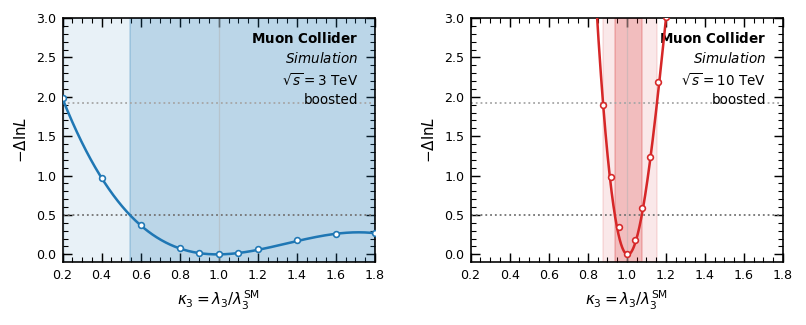

In [3]:
# ══════════════════ EDIT HERE ═══════════════════════════════════════════
# Per panel: kappa3 scan points, -DeltalnL values (any reference; they are
# re-anchored at kappa3=1 below), fit window (None = use all points).
K_3TEV   = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
DLL_3TEV = np.array([1.979128700237756, 0.9747422305260196, 0.37481869568439574, 0.07950971455863609, 0.018069958961136834, 0.0, 0.020455775416379218, 0.06351911551906042, 0.18081546873601617, 0.2563482550651468, 0.2751343986907955])   # REPLACE with your 3 TeV scan
WIN_3TEV = None

K_10TEV   = np.array([0.8, 0.84, 0.88, 0.92, 0.96, 1, 1.04, 1.08, 1.12, 1.16, 1.2])
DLL_10TEV = np.array([5.3480654507179874, 3.330502060135071, 1.8997300463962556, 0.9791748911067479, 0.3419043583875645, 0.0, 0.1875475784030307, 0.5838913955303191, 1.2408765062184166, 2.1933176605294813, 3.0086811893898284])
                                         # REPLACE with your boosted 10 TeV scan
WIN_10TEV = (0.8, 1.2)                   # suggested: fit only the refined grid

TAG_EXTRA = 'boosted'                    # region label inside the panel
OUTPDF    = '/data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_k3.pdf'
# ═════════════════════════════════════════════════════════════════════════


def poly4_cl(k, dll, window=None, n_fine=5000):
    """Shift at kappa3=1, poly4 fit (inside `window`), CL bands referenced
    to the fitted minimum. Returns dict for plotting."""
    k = np.asarray(k, float); dll = np.asarray(dll, float)
    dll = dll - dll[np.argmin(np.abs(k - 1.0))]          # anchor at kappa3=1
    m = np.ones(len(k), bool) if window is None else \
        (k >= window[0] - 1e-9) & (k <= window[1] + 1e-9)
    coef = np.polyfit(k[m], dll[m], 4)
    kf = np.linspace(k[m].min(), k[m].max(), n_fine)
    df = np.polyval(coef, kf)
    sh = np.maximum(df - df.min(), 0.0)                  # fitted-min reference

    def connected(thresh):
        mask = sh < thresh
        i = int(sh.argmin()); lo = hi = i
        while lo > 0 and mask[lo - 1]: lo -= 1
        while hi < len(mask) - 1 and mask[hi + 1]: hi += 1
        return float(kf[lo]), float(kf[hi])

    lo68, hi68 = connected(0.50)
    lo95, hi95 = connected(1.92)
    # display curve re-anchored at kappa3=1 so it passes through the points
    disp = np.maximum(df - np.polyval(coef, 1.0), 0.0)
    return dict(k=k, dll=dll, kf=kf, disp=disp,
                lo68=lo68, hi68=hi68, lo95=lo95, hi95=hi95)


PANELS = [
    ('3 TeV',  ps.C_3TEV,  K_3TEV,  DLL_3TEV,  WIN_3TEV),
    ('10 TeV', ps.C_10TEV, K_10TEV, DLL_10TEV, WIN_10TEV),
]

fig, ax = plt.subplots(1, 2, figsize=ps.SIZE12)
for a, (name, c, k, dll, win) in zip(ax, PANELS):
    P = poly4_cl(k, dll, win)
    a.axvspan(P['lo95'], P['hi95'], color=c, alpha=0.10, zorder=1)   # 95% band
    a.axvspan(P['lo68'], P['hi68'], color=c, alpha=0.22, zorder=2)   # 68% band
    a.plot(P['kf'], P['disp'], '-', color=c, lw=1.4, zorder=4)
    a.plot(P['k'], P['dll'], marker='o', ls='none', mfc='white', mec=c,
           mew=0.9, ms=3.2, zorder=5)
    a.axhline(0.50, color='0.45', ls=':', lw=1.0)
    a.axhline(1.92, color='0.65', ls=':', lw=1.0)
    a.axvline(1.0, color='0.7', lw=0.7, alpha=0.5)
    a.set_xlim(0.2, 1.8); a.set_ylim(-0.1, 3.0)
    a.set_xticks(np.arange(0.2, 1.81, 0.2))
    a.set_xlabel(r'$\kappa_3 = \lambda_3/\lambda_3^{\rm SM}$')
    a.set_ylabel(r'$-\Delta\ln L$')
    ps.hep_tag(a, [rf'$\sqrt{{s}}={name.split()[0]}$ TeV', TAG_EXTRA],
               loc='upper right', simulation=True, fontsize=7.5)
    print(f'{name}: 68% [{P["lo68"]:.3f}, {P["hi68"]:.3f}]   '
          f'95% [{P["lo95"]:.3f}, {P["hi95"]:.3f}]   window={win}')

fig.tight_layout(w_pad=2.0)
fig.savefig(OUTPDF, bbox_inches='tight')
print(f'saved {OUTPDF}')

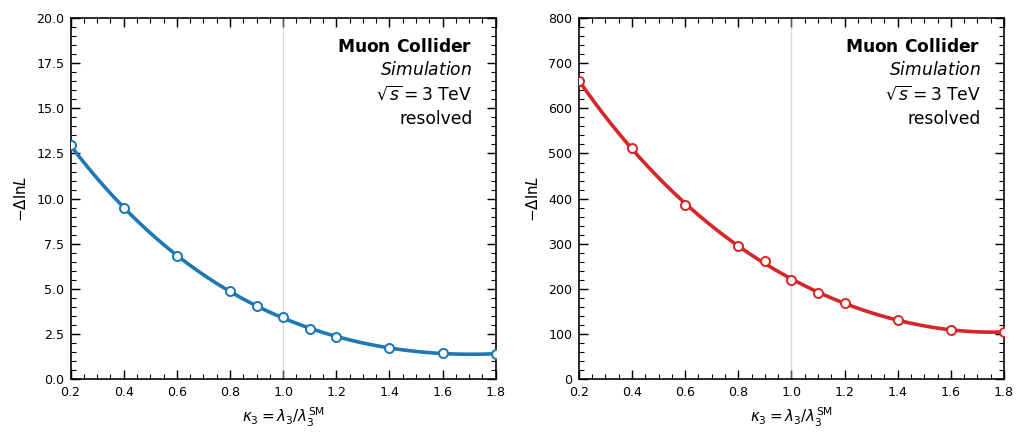

In [4]:

# ==========================================
# 1. 在這裡替換成你自己的數據 (YOUR DATA HERE)
# ==========================================

# --- 左圖數據 (3 TeV) ---
x_data_left = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
y_data_left = np.array([12.950856086473113, 9.50051854058605, 6.85145266368037, 4.864184634932913, 4.0821085613811645, 3.4270720201878078, 2.7907766021670803, 2.3481392499729825, 1.720871731351954, 1.459561082817777, 1.403691502315779])
# y=0.5 對應的 x 範圍 (較深色陰影)
range_05_left = [0.546, 3]
# y=1.96 對應的 x 範圍 (較淺色陰影)
range_196_left = [0, 1.8] # 這裡設定到 1.8 是因為曲線右邊沒有再超過 1.96

# --- 右圖數據 (10 TeV) ---
# x_data_right = np.array([0.2, 0.4, 0.6, 0.8, 0.84, 0.88, 0.92, 0.96, 1, 1.04, 1.08, 1.12, 1.16, 1.2, 1.4, 1.6, 1.8])
# y_data_right = np.array([661.1563022810169, 512.6301828947376, 385.69896145277124, 296.26274969038343, 278.93255342995525, 262.3552762169401, 252.99363774840293, 237.02933102174933, 220.06148079382476, 215.02749071908707, 203.5065937012257, 193.01644044646548, 182.77456907343148, 176.351412960768, 130.95957384023723, 109.66373308330553, 104.60788011803574])

x_data_right = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
y_data_right = np.array([661.1563022810169, 512.6301828947376, 385.69896145277124, 295.2284460347989, 261.4988657043321, 220.36236239999533, 191.2209672797725, 168.36433670884088, 130.95957384023723, 109.66373308330553, 104.60788011803574])

# y=0.5 對應的 x 範圍 (較深色陰影)
range_05_right = [0.936, 1.091]
# y=1.96 對應的 x 範圍 (較淺色陰影)
range_196_right = [0.882, 1.155]


# ==========================================
# 2. 繪圖與排版設定 (Plotting Layout)
# ==========================================

# 建立畫布與子圖 (1x2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.0, 3.5))

def setup_axes(ax, x_data, y_data, range_05, range_196, color, energy_label, x_limits, y_limits):
    """輔助函式：統一設定子圖樣式"""

    # 1. 繪製平滑曲線 (使用 numpy 的 4 次多項式擬合)
    coeffs = np.polyfit(x_data, y_data, 4)
    poly_func = np.poly1d(coeffs)

    # 在可視範圍內產生平滑曲線的點
    x_smooth = np.linspace(x_limits[0], x_limits[1], 300)
    y_smooth = poly_func(x_smooth)

    # 垂直實線 x=1.0 (保留原本中間的基準線)
    ax.axvline(1.0,  color='0.7',  lw=0.7, alpha=0.5)

    # 3. 繪製曲線與數據點 (白底空心圓)
    ax.plot(x_smooth, y_smooth, color=color, linewidth=2, zorder=4)
    ax.plot(x_data, y_data, marker='o', ls='none', mfc='white', mec=color, mew=1.1, ms=5.0, zorder=5)

    # 4. 設定軸標籤與範圍
    ax.set_xlabel(r'$\kappa_3 = \lambda_3/\lambda_3^{\rm{SM}}$')
    ax.set_ylabel(r'$-\Delta\ln L$')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)

    ax.set_xticks(np.arange(0.2, 1.81, 0.2))
    ps.hep_tag(ax, [rf'$\sqrt{{s}}=3$ TeV', 'resolved'], loc='upper right', simulation=True)

# 統一 X, Y 軸極限值 (根據新圖)
shared_x_limits = (0.2, 1.8)

# 套用設定到左圖 (藍色)
setup_axes(ax1, x_data_left, y_data_left, range_05_left, range_196_left,
           color=ps.C_3TEV, energy_label=r"$\sqrt{s} = 3$ TeV",
           x_limits=shared_x_limits, y_limits=(0,20))

# 套用設定到右圖 (紅色)
setup_axes(ax2, x_data_right, y_data_right, range_05_right, range_196_right,
           color=ps.C_10TEV, energy_label=r"$\sqrt{s} = 10$ TeV",
           x_limits=shared_x_limits, y_limits=(0,800))
# 調整子圖之間的間距
plt.tight_layout()

# OUTPDF = "/data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_noHH.pdf"
# fig.savefig(OUTPDF, bbox_inches='tight')
# print(f'saved {OUTPDF}')

plt.show()

3 TeV: kappa3=1  -DeltalnL=3.43  Z=2.62 sigma
10 TeV: kappa3=1  -DeltalnL=220.36  Z=20.99 sigma
saved /data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_noHH.pdf


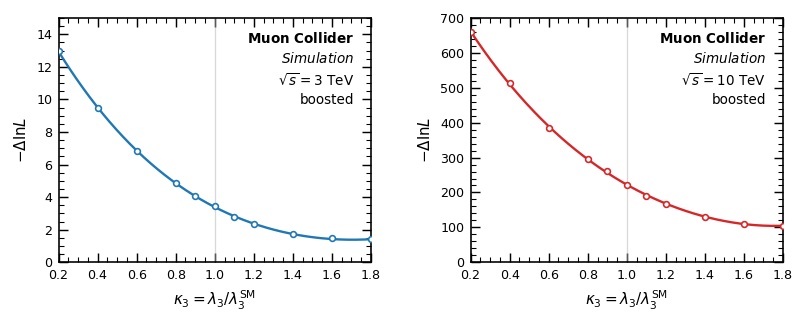

In [5]:
# ══════════════════ EDIT HERE ═══════════════════════════════════════════
# Case-1 scans (null = no HH).  DUMMY values = your Colab boosted scans.
K_3TEV   = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
DLL_3TEV = np.array([12.950856086473113, 9.50051854058605, 6.85145266368037, 4.864184634932913, 4.0821085613811645, 3.4270720201878078, 2.7907766021670803, 2.3481392499729825, 1.720871731351954, 1.459561082817777, 1.403691502315779])          # REPLACE with your scan

K_10TEV   = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8])
DLL_10TEV = np.array([661.1563022810169, 512.6301828947376, 385.69896145277124, 295.2284460347989, 261.4988657043321, 220.36236239999533, 191.2209672797725, 168.36433670884088, 130.95957384023723, 109.66373308330553, 104.60788011803574])   # REPLACE with your scan
YLIM_3TEV  = (0, 15)
YLIM_10TEV = (0, 700)
TAG_EXTRA  = 'boosted'
OUTPDF     = '/data/mucollider/two_boosted/generated_fig/fig_result_boosted_hypo_noHH.pdf'
# ═════════════════════════════════════════════════════════════════════════

PANELS = [
    ('3 TeV',  ps.C_3TEV,  K_3TEV,  DLL_3TEV,  YLIM_3TEV),
    ('10 TeV', ps.C_10TEV, K_10TEV, DLL_10TEV, YLIM_10TEV),
]

kfine = np.linspace(0.2, 1.8, 401)
fig, ax = plt.subplots(1, 2, figsize=ps.SIZE12)
for a, (name, c, k, dll, ylim) in zip(ax, PANELS):
    curve = np.poly1d(np.polyfit(k, dll, 4))(kfine)   # display smoothing
    a.plot(kfine, curve, '-', color=c, lw=1.3, zorder=4)
    a.plot(k, dll, marker='o', ls='none', mfc='white', mec=c,
           mew=0.9, ms=3.2, zorder=5)
    a.axvline(1.0, color='0.7', lw=0.7, alpha=0.5)
    a.set_xlim(0.2, 1.8); a.set_ylim(*ylim)
    a.set_xticks(np.arange(0.2, 1.81, 0.2))
    a.set_xlabel(r'$\kappa_3 = \lambda_3/\lambda_3^{\rm SM}$')
    a.set_ylabel(r'$-\Delta\ln L$')
    ps.hep_tag(a, [rf'$\sqrt{{s}}={name.split()[0]}$ TeV', TAG_EXTRA],
               loc='upper right', simulation=True, fontsize=7.5)
    i1 = int(np.argmin(np.abs(k - 1.0)))
    print(f'{name}: kappa3=1  -DeltalnL={dll[i1]:.2f}  Z={np.sqrt(2*dll[i1]):.2f} sigma')

fig.tight_layout(w_pad=2.0)
fig.savefig(OUTPDF, bbox_inches='tight')
print(f'saved {OUTPDF}')